# Dataset collection

In [20]:
import pandas as pd
import numpy as np 
import urllib.parse
import base64
import re
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score, average_precision_score
from transformers import AutoTokenizer, AutoModel
import seaborn as sns
import torch
import os
from dataclasses import dataclass
from typing import Optional

import warnings
warnings.filterwarnings('ignore')

In [22]:
@dataclass
class ElectionConfig:
    year: int = 2020
    country: str = "US"
    region_filter: str = "US"
    election_date: str = "2020-11-03"  # general election day
    ad_period_start: str = "2020-01-01"
    ad_period_end: str = "2020-11-03"
    offices: tuple = ("US PRESIDENT",)
    competition_parties: tuple = ("DEMOCRAT", "REPUBLICAN")
    competition_classes: tuple = (
        "Democratic", "Republican", "Anti-Republican", "Anti-Trump"
    )

CFG = ElectionConfig()

ELECTION_STAGES = pd.DataFrame([
    {"stage": "dem_primary",   "stage_start": "2020-02-03", "stage_end": "2020-06-06", "election_datetime": "2020-06-06"},
    {"stage": "conventions",   "stage_start": "2020-06-07", "stage_end": "2020-08-31", "election_datetime": "2020-08-20"},
    {"stage": "general",       "stage_start": "2020-09-01", "stage_end": "2020-11-03", "election_datetime": "2020-11-03"},
    {"stage": "post_election","stage_start": "2020-11-04", "stage_end": "2020-12-31", "election_datetime": None},
])
ELECTION_STAGES["stage_start"] = pd.to_datetime(ELECTION_STAGES["stage_start"])
ELECTION_STAGES["stage_end"]   = pd.to_datetime(ELECTION_STAGES["stage_end"])

AD_SETTINGS = {
    "YEAR": 2020,
    "COUNTRY": "US",
    "REGIONS": "US",
    "START_DATE": "2020-01-01",
    "END_DATE": "2020-11-03",
    "COMPETITION_CLASSES": ["Democratic", "Republican", "Anti-Republican", "Anti-Trump"],
}

ELECTION_PARTY_SIDE = {
    "DEMOCRAT":   "democratic",
    "REPUBLICAN": "republican",
}

### Load tables

In [2]:
os.listdir("./google-political-ads-transparency-bundle/")

['google-political-ads-campaign-targeting.csv',
 'google-political-ads-advertiser-geo-spend.csv',
 'advertiser_id_mapping.csv',
 'google-political-ads-advertiser-declared-stats.csv',
 'google-political-ads-advertiser-weekly-spend.csv',
 'google-political-ads-creative-stats.csv',
 'creative_id_mapping.csv',
 'google-political-ads-advertiser-stats.csv',
 'google-political-ads-top-keywords-history.csv',
 'README.txt',
 'google-political-ads-geo-spend.csv',
 'google-political-ads-updated.csv']

In [3]:
stats = pd.read_csv("./google-political-ads-transparency-bundle/google-political-ads-advertiser-stats.csv")
creative_stats = pd.read_csv("./google-political-ads-transparency-bundle/google-political-ads-creative-stats.csv")
declared_stats = pd.read_csv("./google-political-ads-transparency-bundle/google-political-ads-advertiser-declared-stats.csv")
creative_stats.head()

,Ad_ID,Ad_URL,Ad_Type,Regions,Advertiser_ID,Advertiser_Name,Ad_Campaigns_List,Date_Range_Start,Date_Range_End,Num_of_Days,...,Spend_Range_Max_BRL,Spend_Range_Min_ARS,Spend_Range_Max_ARS,Spend_Range_Min_ZAR,Spend_Range_Max_ZAR,Spend_Range_Min_CLP,Spend_Range_Max_CLP,Spend_Range_Min_MXN,Spend_Range_Max_MXN,Unnamed: 59
0,CR04990084560034201601,https://adstransparency.google.com/advertiser/...,TEXT,US,AR15354116347822866433,Dolan Committee,NaN,2024-08-06,2024-09-03,29,...,500.0,0,15000.0,0,15000,0,50000.0,0,1000,NaN
1,CR02773067831053385729,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-27,2020-03-08,10,...,500.0,0,15000.0,0,15000,0,50000.0,0,1000,NaN
2,CR08370531994479624193,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-10,2020-03-07,27,...,500.0,0,15000.0,0,15000,0,50000.0,0,1000,NaN
3,CR07589526895037775873,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-07,2020-03-08,28,...,500.0,0,15000.0,0,15000,0,50000.0,0,1000,NaN
4,CR16244460216425381889,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-10,2020-03-07,26,...,500.0,0,15000.0,0,15000,0,50000.0,0,1000,NaN


In [4]:
def add_date_columns(df, date_column):
    df[date_column] = pd.to_datetime(df[date_column])

    df[f'{date_column}_d'] = df[date_column].dt.day
    df[f'{date_column}_m'] = df[date_column].dt.month
    df[f'{date_column}_y'] = df[date_column].dt.year
    df[f'{date_column}_w'] = df[date_column].dt.isocalendar().week

add_date_columns(creative_stats, "Date_Range_Start")
add_date_columns(creative_stats, "Date_Range_End")
creative_stats.head()

,Ad_ID,Ad_URL,Ad_Type,Regions,Advertiser_ID,Advertiser_Name,Ad_Campaigns_List,Date_Range_Start,Date_Range_End,Num_of_Days,...,Spend_Range_Max_MXN,Unnamed: 59,Date_Range_Start_d,Date_Range_Start_m,Date_Range_Start_y,Date_Range_Start_w,Date_Range_End_d,Date_Range_End_m,Date_Range_End_y,Date_Range_End_w
0,CR04990084560034201601,https://adstransparency.google.com/advertiser/...,TEXT,US,AR15354116347822866433,Dolan Committee,NaN,2024-08-06,2024-09-03,29,...,1000,NaN,6,8,2024,32,3,9,2024,36
1,CR02773067831053385729,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-27,2020-03-08,10,...,1000,NaN,27,2,2020,9,8,3,2020,10
2,CR08370531994479624193,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-10,2020-03-07,27,...,1000,NaN,10,2,2020,7,7,3,2020,10
3,CR07589526895037775873,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-07,2020-03-08,28,...,1000,NaN,7,2,2020,6,8,3,2020,10
4,CR16244460216425381889,https://adstransparency.google.com/advertiser/...,TEXT,US,AR16258470056147550209,JEANNE FOR CONGRESS,NaN,2020-02-10,2020-03-07,26,...,1000,NaN,10,2,2020,7,7,3,2020,10


In [5]:
# Option 1: Ads that STARTED in 2020 (most relevant for 2020 candidates)
us_2020_ads = creative_stats[
    (creative_stats["Date_Range_Start_y"] == 2020) & 
    (creative_stats["Regions"] == "US") &
    (creative_stats["Date_Range_Start"] >= "2020-01-01") &
    (creative_stats["Date_Range_Start"] <= "2020-11-03")  # Election day
]

# Option 2: Ads active during the peak election period (Jun-Nov 2020)
peak_2020_ads = creative_stats[
    (creative_stats["Regions"] == "US") &
    (creative_stats["Date_Range_End"] >= "2020-06-01") &  # Active during peak season
    (creative_stats["Date_Range_Start"] <= "2020-11-03") &  # Started before election
    (creative_stats["Date_Range_Start_y"] >= 2019)  # But not too old
]

california_candidates = declared_stats[
    declared_stats["Region"] == "US-CA"
]
ads_with_candidates = us_2020_ads.merge(
    california_candidates[["Advertiser_ID", "Advertiser_Declared_Scope", "Advertiser_Declared_Promoter_Name"]],
    left_on="Advertiser_ID",
    right_on="Advertiser_ID",
    how="inner"
)

print(f"Ads starting in 2020: {len(us_2020_ads)}")
print(f"Ads active during peak 2020: {len(peak_2020_ads)}")

print("Range start")
print(us_2020_ads["Date_Range_Start_y"].value_counts())
print("Range start")
print(peak_2020_ads["Date_Range_Start_y"].value_counts())
print("Range start")
print(ads_with_candidates["Date_Range_Start_y"].value_counts())

Ads starting in 2020: 325260
Ads active during peak 2020: 227298
Range start
Date_Range_Start_y
2020    325260
Name: count, dtype: int64
Range start
Date_Range_Start_y
2020    219666
2019      7632
Name: count, dtype: int64
Range start
Date_Range_Start_y
2020    1570
Name: count, dtype: int64


### Analyze data

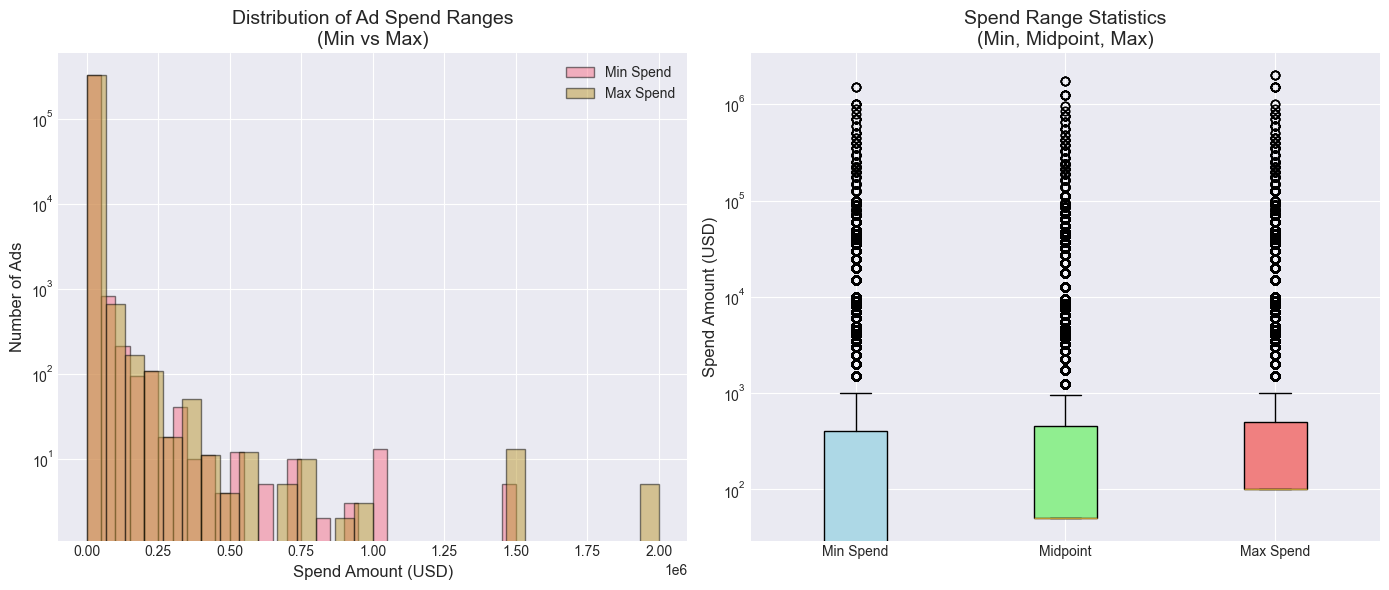


=== Spend Range Statistics ===
Min Spend - Mean: $1,435, Median: $0
Max Spend - Mean: $1,821, Median: $100
Average Range Width: $387


In [6]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Use your filtered 2020 US election ads
us_2020_election_ads = creative_stats[
    (creative_stats["Regions"] == "US") &
    (creative_stats["Date_Range_Start_y"] == 2020) &
    (creative_stats["Date_Range_End_y"] == 2020) &
    (creative_stats["Date_Range_Start"] >= "2020-01-01") &
    (creative_stats["Date_Range_Start"] <= "2020-11-03") &
    (creative_stats["Spend_Range_Max_USD"] > 0)
].copy()

# Calculate min and max spend for each ad
us_2020_election_ads['spend_midpoint'] = (
    us_2020_election_ads['Spend_Range_Min_USD'] + 
    us_2020_election_ads['Spend_Range_Max_USD']
) / 2

# Prepare data for min-max visualization
spend_ranges = us_2020_election_ads[['Spend_Range_Min_USD', 'Spend_Range_Max_USD', 'spend_midpoint']].dropna()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Distribution of spend ranges (min vs max)
ax1 = axes[0]
ax1.hist(spend_ranges['Spend_Range_Min_USD'], bins=30, alpha=0.5, label='Min Spend', edgecolor='black')
ax1.hist(spend_ranges['Spend_Range_Max_USD'], bins=30, alpha=0.5, label='Max Spend', edgecolor='black')
ax1.set_xlabel('Spend Amount (USD)', fontsize=12)
ax1.set_ylabel('Number of Ads', fontsize=12)
ax1.set_title('Distribution of Ad Spend Ranges\n(Min vs Max)', fontsize=14)
ax1.legend()
ax1.set_yscale('log')  # Log scale to see distribution better

# Plot 2: Box plot of min, max, and midpoint
ax2 = axes[1]
box_data = [spend_ranges['Spend_Range_Min_USD'], 
            spend_ranges['spend_midpoint'], 
            spend_ranges['Spend_Range_Max_USD']]
bp = ax2.boxplot(box_data, labels=['Min Spend', 'Midpoint', 'Max Spend'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
bp['boxes'][2].set_facecolor('lightcoral')
ax2.set_ylabel('Spend Amount (USD)', fontsize=12)
ax2.set_title('Spend Range Statistics\n(Min, Midpoint, Max)', fontsize=14)
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Spend Range Statistics ===")
print(f"Min Spend - Mean: ${spend_ranges['Spend_Range_Min_USD'].mean():,.0f}, Median: ${spend_ranges['Spend_Range_Min_USD'].median():,.0f}")
print(f"Max Spend - Mean: ${spend_ranges['Spend_Range_Max_USD'].mean():,.0f}, Median: ${spend_ranges['Spend_Range_Max_USD'].median():,.0f}")
print(f"Average Range Width: ${(spend_ranges['Spend_Range_Max_USD'] - spend_ranges['Spend_Range_Min_USD']).mean():,.0f}")

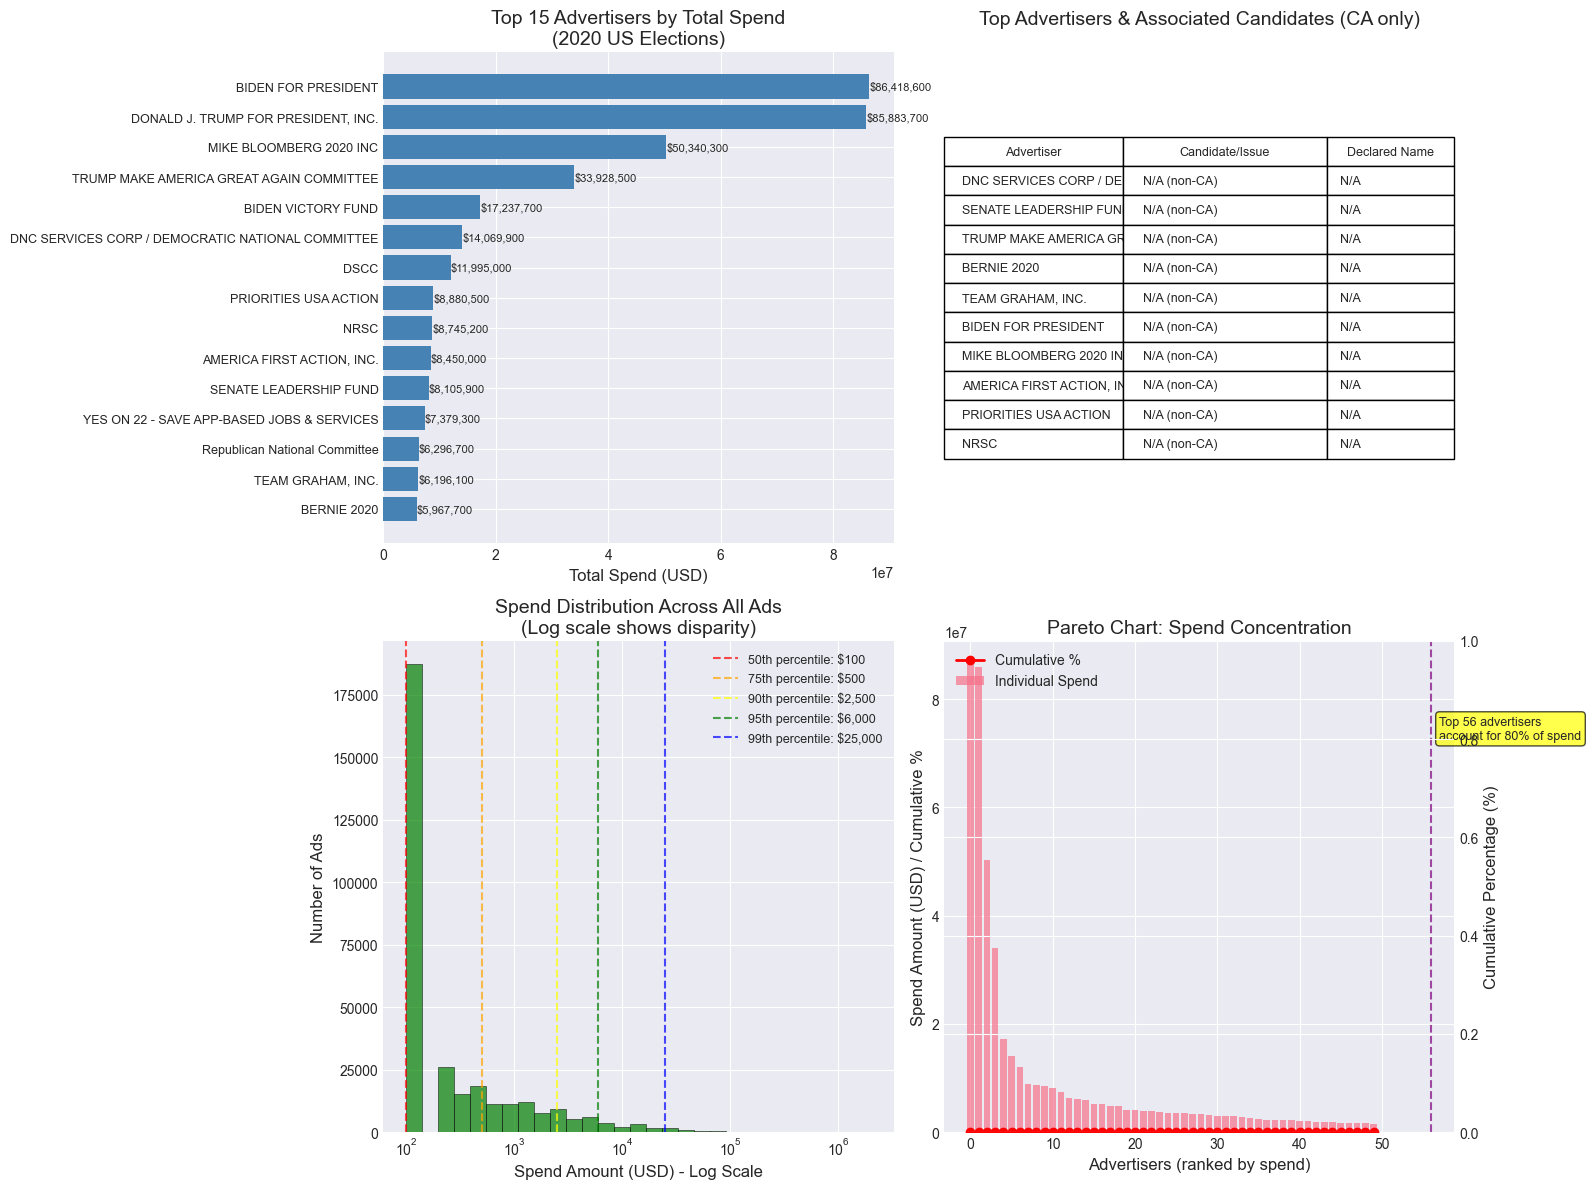

In [ ]:
# Aggregate spend by advertiser
advertiser_spend = us_2020_election_ads.groupby('Advertiser_Name').agg({
    'Spend_Range_Max_USD': ['sum', 'count', 'mean'],
    'Ad_ID': 'count'
}).round(0)
advertiser_spend.columns = ['total_spend', 'num_ads', 'avg_spend_per_ad', 'ad_count']
advertiser_spend = advertiser_spend.sort_values('total_spend', ascending=False)

top_spenders = advertiser_spend.head(15)

candidate_info = declared_stats[declared_stats['Region'] == 'US-CA'][['Advertiser_ID', 'Advertiser_Declared_Scope', 'Advertiser_Declared_Name']]
candidate_info.columns = ['Advertiser_ID', 'candidate_scope', 'declared_name']

top_spenders_with_candidates = us_2020_election_ads[us_2020_election_ads['Advertiser_Name'].isin(top_spenders.index)].merge(
    candidate_info, on='Advertiser_ID', how='left'
).drop_duplicates('Advertiser_Name')[['Advertiser_Name', 'candidate_scope', 'declared_name']]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
bars = ax1.barh(range(len(top_spenders)), top_spenders['total_spend'].values, color='steelblue')
ax1.set_yticks(range(len(top_spenders)))
ax1.set_yticklabels(top_spenders.index, fontsize=9)
ax1.set_xlabel('Total Spend (USD)', fontsize=12)
ax1.set_title('Top 15 Advertisers by Total Spend\n(2020 US Elections)', fontsize=14)
ax1.invert_yaxis()
for i, (bar, spend) in enumerate(zip(bars, top_spenders['total_spend'].values)):
    ax1.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2, 
             f'${spend:,.0f}', va='center', fontsize=8)

ax2 = axes[0, 1]
ax2.axis('tight')
ax2.axis('off')
candidate_table_data = []
for idx, row in top_spenders_with_candidates.head(10).iterrows():
    candidate_table_data.append([
        row['Advertiser_Name'][:30],
        row['candidate_scope'][:50] if pd.notna(row['candidate_scope']) else 'N/A (non-CA)',
        row['declared_name'][:30] if pd.notna(row['declared_name']) else 'N/A'
    ])
table = ax2.table(cellText=candidate_table_data,
                  colLabels=['Advertiser', 'Candidate/Issue', 'Declared Name'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.35, 0.4, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax2.set_title('Top Advertisers & Associated Candidates (CA only)', fontsize=14, pad=20)

ax3 = axes[1, 0]
bins = np.logspace(np.log10(100), np.log10(us_2020_election_ads['Spend_Range_Max_USD'].max()), 30)
ax3.hist(us_2020_election_ads['Spend_Range_Max_USD'], bins=bins, 
         alpha=0.7, color='green', edgecolor='black', linewidth=0.5)
ax3.set_xscale('log')
ax3.set_xlabel('Spend Amount (USD) - Log Scale', fontsize=12)
ax3.set_ylabel('Number of Ads', fontsize=12)
ax3.set_title('Spend Distribution Across All Ads\n(Log scale shows disparity)', fontsize=14)

percentiles = [50, 75, 90, 95, 99]
colors = ['red', 'orange', 'yellow', 'green', 'blue']
for p, c in zip(percentiles, colors):
    val = us_2020_election_ads['Spend_Range_Max_USD'].quantile(p/100)
    ax3.axvline(val, color=c, linestyle='--', alpha=0.7, label=f'{p}th percentile: ${val:,.0f}')
ax3.legend(fontsize=9)

ax4 = axes[1, 1]
advertiser_spend_sorted = advertiser_spend.sort_values('total_spend', ascending=False)
cumulative_percent = advertiser_spend_sorted['total_spend'].cumsum() / advertiser_spend_sorted['total_spend'].sum() * 100

x = range(len(advertiser_spend_sorted[:50]))
ax4.bar(x, advertiser_spend_sorted['total_spend'][:50].values, alpha=0.7, label='Individual Spend')
ax4.plot(x, cumulative_percent[:50].values, 'r-o', linewidth=2, label='Cumulative %')
ax4.set_xlabel('Advertisers (ranked by spend)', fontsize=12)
ax4.set_ylabel('Spend Amount (USD) / Cumulative %', fontsize=12)
ax4.set_title('Pareto Chart: Spend Concentration', fontsize=14)
ax4.legend(loc='upper left')
ax4_twin = ax4.twinx()
ax4_twin.set_ylabel('Cumulative Percentage (%)', fontsize=12)

spend_80_pct = np.where(cumulative_percent <= 80)[0][-1] + 1
ax4.axvline(x=spend_80_pct, color='purple', linestyle='--', alpha=0.7)
ax4.text(spend_80_pct + 1, ax4.get_ylim()[1] * 0.8, 
         f'Top {spend_80_pct} advertisers\naccount for 80% of spend', 
         fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

In [8]:
candidate_table_data

[['DNC SERVICES CORP / DEMOCRATIC', 'N/A (non-CA)', 'N/A'],
 ['SENATE LEADERSHIP FUND', 'N/A (non-CA)', 'N/A'],
 ['TRUMP MAKE AMERICA GREAT AGAIN', 'N/A (non-CA)', 'N/A'],
 ['BERNIE 2020', 'N/A (non-CA)', 'N/A'],
 ['TEAM GRAHAM, INC.', 'N/A (non-CA)', 'N/A'],
 ['BIDEN FOR PRESIDENT', 'N/A (non-CA)', 'N/A'],
 ['MIKE BLOOMBERG 2020 INC', 'N/A (non-CA)', 'N/A'],
 ['AMERICA FIRST ACTION, INC.', 'N/A (non-CA)', 'N/A'],
 ['PRIORITIES USA ACTION', 'N/A (non-CA)', 'N/A'],
 ['NRSC', 'N/A (non-CA)', 'N/A']]

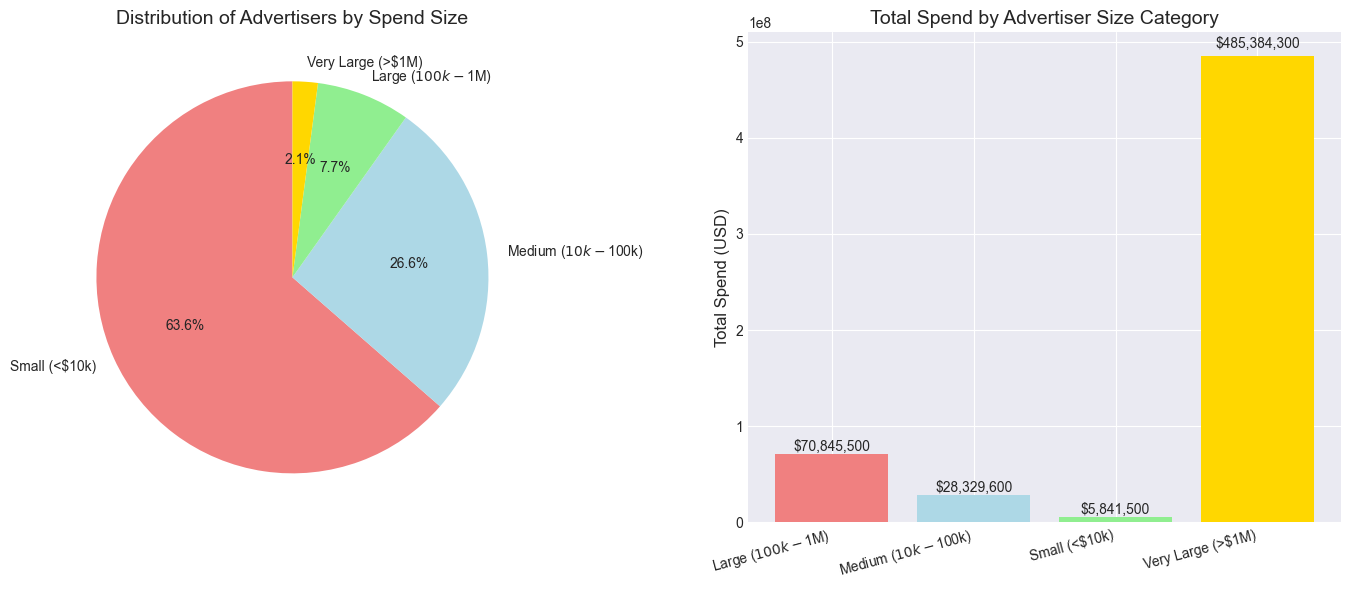


=== Spend Distribution Summary ===
Total Advertisers: 3217
Total Spend: $590,400,900

Advertiser Size Breakdown:
  Small (<$10k): 2045 advertisers, $5,841,500 (1.0% of total)
  Medium ($10k-$100k): 856 advertisers, $28,329,600 (4.8% of total)
  Large ($100k-$1M): 249 advertisers, $70,845,500 (12.0% of total)
  Very Large (>$1M): 67 advertisers, $485,384,300 (82.2% of total)


In [ ]:
def classify_spender(total_spend):
    if total_spend < 10000:
        return 'Small (<$10k)'
    elif total_spend < 100000:
        return 'Medium ($10k-$100k)'
    elif total_spend < 1000000:
        return 'Large ($100k-$1M)'
    else:
        return 'Very Large (>$1M)'

advertiser_spend['spender_size'] = advertiser_spend['total_spend'].apply(classify_spender)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
size_counts = advertiser_spend['spender_size'].value_counts()
colors_pie = ['lightcoral', 'lightblue', 'lightgreen', 'gold']
wedges, texts, autotexts = ax1.pie(size_counts.values, labels=size_counts.index, 
                                     autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax1.set_title('Distribution of Advertisers by Spend Size', fontsize=14)

ax2 = axes[1]
size_spend = advertiser_spend.groupby('spender_size')['total_spend'].sum().sort_index()
bars = ax2.bar(range(len(size_spend)), size_spend.values, color=colors_pie)
ax2.set_xticks(range(len(size_spend)))
ax2.set_xticklabels(size_spend.index, rotation=15, ha='right')
ax2.set_ylabel('Total Spend (USD)', fontsize=12)
ax2.set_title('Total Spend by Advertiser Size Category', fontsize=14)

for bar, spend in zip(bars, size_spend.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spend*0.01,
             f'${spend:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== Spend Distribution Summary ===")
print(f"Total Advertisers: {len(advertiser_spend)}")
print(f"Total Spend: ${advertiser_spend['total_spend'].sum():,.0f}")
print(f"\nAdvertiser Size Breakdown:")
for size in ['Small (<$10k)', 'Medium ($10k-$100k)', 'Large ($100k-$1M)', 'Very Large (>$1M)']:
    count = advertiser_spend[advertiser_spend['spender_size'] == size].shape[0]
    spend = advertiser_spend[advertiser_spend['spender_size'] == size]['total_spend'].sum()
    pct_spend = (spend / advertiser_spend['total_spend'].sum()) * 100
    print(f"  {size}: {count} advertisers, ${spend:,.0f} ({pct_spend:.1f}% of total)")

In [ ]:
advertiser_spend_sorted = advertiser_spend.sort_values('total_spend', ascending=False)
advertiser_spend_sorted['cumulative_spend'] = advertiser_spend_sorted['total_spend'].cumsum()
advertiser_spend_sorted['cumulative_percent'] = (advertiser_spend_sorted['cumulative_spend'] / advertiser_spend_sorted['total_spend'].sum()) * 100

top_90_advertisers = advertiser_spend_sorted[advertiser_spend_sorted['cumulative_percent'] <= 90]
print(f"Top {len(top_90_advertisers)} advertisers account for 90% of total spend\n")
print("=" * 100)

print(f"{'Rank':<5} {'Advertiser Name':<50} {'Total Spend':<15} {'Cumulative %':<12} {'# Ads':<8}")
print("-" * 100)

for idx, (name, row) in enumerate(top_90_advertisers.iterrows(), 1):
    print(f"{idx:<5} {name[:50]:<50} ${row['total_spend']:>12,.0f}  {row['cumulative_percent']:>6.1f}%      {row['num_ads']:>5}")

print("=" * 100)
print(f"\nTotal advertisers to label: {len(top_90_advertisers)}")
print(f"Total spend covered: ${top_90_advertisers['total_spend'].sum():,.0f}")
print(f"Percentage of total: {top_90_advertisers['total_spend'].sum() / advertiser_spend_sorted['total_spend'].sum() * 100:.1f}%")

Top 163 advertisers account for 90% of total spend

Rank  Advertiser Name                                    Total Spend     Cumulative % # Ads   
----------------------------------------------------------------------------------------------------
1     BIDEN FOR PRESIDENT                                $  86,418,600    14.6%      57464
2     DONALD J. TRUMP FOR PRESIDENT, INC.                $  85,883,700    29.2%      22537
3     MIKE BLOOMBERG 2020 INC                            $  50,340,300    37.7%      56714
4     TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE           $  33,928,500    43.5%      14121
5     BIDEN VICTORY FUND                                 $  17,237,700    46.4%        328
6     DNC SERVICES CORP / DEMOCRATIC NATIONAL COMMITTEE  $  14,069,900    48.8%       5595
7     DSCC                                               $  11,995,000    50.8%       1104
8     PRIORITIES USA ACTION                              $   8,880,500    52.3%       4239
9     NRSC              

In [20]:
top_90_advertisers["Rank"] = np.arange(1, len(top_90_advertisers) + 1)
top_90_advertisers["Advertiser_Name"] = top_90_advertisers.index

top_90_advertisers[["Rank", "Advertiser_Name"]].head()

,Rank,Advertiser_Name
Advertiser_Name,,
BIDEN FOR PRESIDENT,1,BIDEN FOR PRESIDENT
"DONALD J. TRUMP FOR PRESIDENT, INC.",2,"DONALD J. TRUMP FOR PRESIDENT, INC."
MIKE BLOOMBERG 2020 INC,3,MIKE BLOOMBERG 2020 INC
TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,4,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE
BIDEN VICTORY FUND,5,BIDEN VICTORY FUND


### Load advertiser markdown

In [ ]:
def parse_markdown_table(table_text):
    lines = [line.strip() for line in table_text.strip().split('\n') if line.strip()]
    
    # Skip the separator line (---|---|...)
    header = [col.strip() for col in lines[0].split('|')[1:-1]]
    data_lines = lines[2:]
    
    rows = []
    for line in data_lines:
        cells = [cell.strip().replace("**", "").replace("**", "").replace("`", "").replace("`", "") for cell in line.split('|')[1:-1]]
        rows.append(cells)
    
    return pd.DataFrame(rows, columns=header)

with open('advertiser_classification.txt', 'r') as file:
    table_text = file.read()
classified = parse_markdown_table(table_text)

classified['Advertiser'] = classified['Advertiser'].str.strip()
classified['CLASS'] = classified['CLASS'].str.strip()
classified['Code'] = classified['Code'].str.strip()

classified['Rank'] = classified['Rank'].astype(int)
top_90_advertisers['Rank'] = top_90_advertisers['Rank'].astype(int)

classified_clean = classified.drop(columns=['Rank', 'Advertiser'], errors='ignore')  # Remove if exists
classified_clean = classified_clean.reset_index(drop=True)
classified = classified.rename(columns={'Rank': 'Classified_Rank'})

classified = classified.merge(
    top_90_advertisers[['Advertiser_Name']],
    left_on='Classified_Rank',
    right_on='Rank',
    how='left'
)
classified['Advertiser'] = classified['Advertiser_Name'].str.strip()

print(f"Loaded {len(classified)} classified advertisers")
print("\nFirst few rows:")
print(classified.head())
print("\nUnique CLASS values:")
print(classified['CLASS'].value_counts())

Loaded 163 classified advertisers

First few rows:
   Classified_Rank                                Advertiser  \
0                1                       BIDEN FOR PRESIDENT   
1                2       DONALD J. TRUMP FOR PRESIDENT, INC.   
2                3                   MIKE BLOOMBERG 2020 INC   
3                4  TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE   
4                5                        BIDEN VICTORY FUND   

                           2020 assignment / context       CLASS  \
0           Official Joe Biden presidential campaign  Democratic   
1        Official Donald Trump presidential campaign  Republican   
2  Michael Bloomberg Democratic presidential prim...  Democratic   
3            Trump/Pence joint fundraising committee  Republican   
4              Biden/DNC joint fundraising committee  Democratic   

             Code                           Advertiser_Name  
0  DEM_PRES_BIDEN                       BIDEN FOR PRESIDENT  
1  REP_PRES_TRUMP       DONALD 

In [52]:
advertiser_spend

,total_spend,num_ads,avg_spend_per_ad,ad_count,spender_size
Advertiser_Name,,,,,
BIDEN FOR PRESIDENT,86418600.0,57464,1504.0,57464,Very Large (>$1M)
"DONALD J. TRUMP FOR PRESIDENT, INC.",85883700.0,22537,3811.0,22537,Very Large (>$1M)
MIKE BLOOMBERG 2020 INC,50340300.0,56714,888.0,56714,Very Large (>$1M)
TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,33928500.0,14121,2403.0,14121,Very Large (>$1M)
BIDEN VICTORY FUND,17237700.0,328,52554.0,328,Very Large (>$1M)
...,...,...,...,...,...
HORCH FOR MAINE 2020 CAMPAIGN,100.0,1,100.0,1,Small (<$10k)
WHEN WE ALL VOTE,100.0,1,100.0,1,Small (<$10k)
TRESLYN PATTERSON,100.0,1,100.0,1,Small (<$10k)


In [53]:
advertiser_spend.index = advertiser_spend.index.str.strip()

advertiser_with_class = advertiser_spend.merge(
    classified[['Advertiser', 'CLASS', 'Code', '2020 assignment / context']],
    left_on=advertiser_spend.index,
    right_on='Advertiser',
    how='left'
)

advertiser_with_class['CLASS'].isna().sum()

3054

In [55]:
advertiser_with_class[advertiser_with_class['spender_size'] == 'Very Large (>$1M)']['CLASS'].value_counts()

CLASS
Democratic          34
Republican          24
Commercial/Media     4
Anti-Republican      2
Anti-Trump           2
Unsure/Issue         1
Name: count, dtype: int64

In [58]:
advertiser_with_class[advertiser_with_class['Advertiser'] == "BIDEN VICTORY FUND"]

,total_spend,num_ads,avg_spend_per_ad,ad_count,spender_size,Advertiser,CLASS,Code,2020 assignment / context
4,17237700.0,328,52554.0,328,Very Large (>$1M),BIDEN VICTORY FUND,Democratic,DEM_PRES_BIDEN,Biden/DNC joint fundraising committee


In [ ]:
# ============================================
# MERGE WITH SPEND DATA
# ============================================

advertiser_with_class = advertiser_with_class.rename(columns={'key_0': 'Advertiser'})

advertiser_with_class['CLASS'] = advertiser_with_class['CLASS'].fillna('Unmarked')
advertiser_with_class['Code'] = advertiser_with_class['Code'].fillna('OTHER_UNKNOWN')

print(f"\nMerged {len(advertiser_with_class)} advertisers")
print(f"Classified: {advertiser_with_class['CLASS'].notna().sum()}")
print(f"Unclassified: {advertiser_with_class['CLASS'].isna().sum()}")

# ============================================
# AGGREGATE SPEND BY CLASSIFICATION
# ============================================

spend_by_class = advertiser_with_class.groupby('CLASS').agg({
    'total_spend': 'sum',
    'num_ads': 'sum',
    'Advertiser': 'count'
}).rename(columns={'Advertiser': 'num_advertisers'}).sort_values('total_spend', ascending=False)

print("\n=== Spend by CLASS ===")
print(spend_by_class)
spend_by_code = advertiser_with_class.groupby('Code').agg({
    'total_spend': 'sum',
    'num_ads': 'sum',
    'Advertiser': 'count'
}).rename(columns={'Advertiser': 'num_advertisers'}).sort_values('total_spend', ascending=False)

print("\n=== Top 10 by Code ===")
print(spend_by_code.head(10))


Merged 3217 advertisers
Classified: 3217
Unclassified: 0

=== Spend by CLASS ===
                        total_spend  num_ads  num_advertisers
CLASS                                                        
Democratic              291097100.0   159406               90
Republican              212081800.0    60152               44
Unmarked                 59056700.0    66082             3054
Commercial/Media          8974700.0    32593               10
Unsure/Issue              7725800.0     1404               11
Anti-Republican           5646400.0      449                3
Anti-Trump                5535500.0     4065                4
Nonpartisan/Government     282900.0       58                1

=== Top 10 by Code ===
                          total_spend  num_ads  num_advertisers
Code                                                           
REP_PRES_TRUMP            126108900.0    39284                3
DEM_PRES_BIDEN            120626900.0    63998                8
DEM_PRIMARY       

In [ ]:
plt.switch_backend('Agg')
import matplotlib
matplotlib.use('Agg')

advertiser_with_class['Advertiser_Name'] = advertiser_with_class['Advertiser'].str.strip()

fig = plt.figure(figsize=(14, 10))
ax1 = plt.subplot(2, 2, 1)
top_20 = advertiser_with_class.nlargest(20, 'total_spend')
colors = ['blue' if c == 'Democratic' else 'red' if c == 'Republican' else 'gray' 
          for c in top_20['CLASS']]
bars = ax1.barh(range(len(top_20)), top_20['total_spend'].values / 1e6, color=colors)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels([name[:30] for name in top_20['Advertiser_Name'].values], fontsize=8)
ax1.set_xlabel('Spend (Millions USD)')
ax1.set_title('Top 20 Ad Spend by Advertiser')
ax1.invert_yaxis()

legend_elements = [Patch(facecolor='blue', label='Democratic'),
                   Patch(facecolor='red', label='Republican'),
                   Patch(facecolor='gray', label='Other')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8)

ax2 = plt.subplot(2, 2, 2)
spend_by_party = advertiser_with_class.groupby('CLASS')['total_spend'].sum()
colors_pie = ['blue' if 'Democratic' in p else 'red' if 'Republican' in p else 'gray' 
              for p in spend_by_party.index]
wedges, texts, autotexts = ax2.pie(spend_by_party.values, 
                                     labels=spend_by_party.index,
                                     autopct='%1.1f%%',
                                     colors=colors_pie,
                                     startangle=90)
ax2.set_title('Total Spend by Party', fontsize=12, fontweight='bold')

ax3 = plt.subplot(2, 2, 3)
bins = np.logspace(3, 9, 20)
ax3.hist(advertiser_spend['total_spend'].values, bins=bins, 
         alpha=0.7, color='steelblue', edgecolor='black')
ax3.set_xscale('log')
ax3.set_xlabel('Total Spend per Advertiser (USD - Log Scale)')
ax3.set_ylabel('Number of Advertisers')
ax3.set_title('Advertiser Spend Distribution')
ax3.axvline(advertiser_spend['total_spend'].median(), color='red', linestyle='--', 
            label=f'Median: ${advertiser_spend["total_spend"].median():,.0f}')
ax3.legend()

ax4 = plt.subplot(2, 2, 4)
if 'Code' in advertiser_with_class.columns and advertiser_with_class['Code'].notna().any():
    spend_by_code = advertiser_with_class[advertiser_with_class['Code'].notna()].groupby('Code')['total_spend'].sum().nlargest(10)
    colors_code = ['blue' if 'DEM' in c else 'red' if 'REP' in c else 'gray' for c in spend_by_code.index]
    bars = ax4.barh(range(len(spend_by_code)), spend_by_code.values / 1e6, color=colors_code)
    ax4.set_yticks(range(len(spend_by_code)))
    ax4.set_yticklabels(spend_by_code.index, fontsize=8)
    ax4.set_xlabel('Spend (Millions USD)')
    ax4.set_title('Top 10 Campaign Codes')
    ax4.invert_yaxis()
else:
    top_classified = advertiser_with_class[advertiser_with_class['CLASS'] != 'Other'].nlargest(10, 'total_spend')
    bars = ax4.barh(range(len(top_classified)), top_classified['total_spend'].values / 1e6,
                    color=['blue' if c == 'Democratic' else 'red' for c in top_classified['CLASS']])
    ax4.set_yticks(range(len(top_classified)))
    ax4.set_yticklabels([f"{name[:25]} ({cls})" for name, cls in 
                         zip(top_classified['Advertiser_Name'].values, top_classified['CLASS'].values)], fontsize=7)
    ax4.set_xlabel('Spend (Millions USD)')
    ax4.set_title('Top 10 Classified Advertisers')
    ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('ad_spend_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved as 'ad_spend_analysis.png'")


✅ Plot saved as 'ad_spend_analysis.png'


In [61]:
advertiser_with_class.to_csv('advertiser_with_class.csv', index=False)

### Filtering CountyPress [2020]

In [ ]:
def build_election_results(cfg: ElectionConfig) -> pd.DataFrame:
    raw = pd.read_csv("./elections/countypres_2000-2024.csv")

    df = raw[
        (raw["year"] == cfg.year) &
        (raw["office"].isin(cfg.offices)) &
        (raw["party"].isin(cfg.competition_parties))
    ].copy()

    MODE_CANONICAL = {
        "TOTAL": "total",
        "ELECTION DAY": "election_day",
        "ABSENTEE": "absentee",
        "ABSENTEE BY MAIL": "absentee_mail",
        "EARLY VOTING": "early_voting",
        "EARLY VOTE": "early_voting",
        "EARLY": "early_voting",
        "ADVANCED VOTING": "early_voting",
        "ONE STOP": "early_voting",
        "MAIL": "mail",
        "MAIL-IN": "mail",
        "PROVISIONAL": "provisional",
        "PROV": "provisional",
        "FAILSAFE": "failsafe",
        "FAILSAFE PROVISIONAL": "failsafe",
        "IN-PERSON ABSENTEE": "absentee_in_person",
        "2ND ABSENTEE": "absentee_2nd",
        "VOTE CENTER": "vote_center",
        "LATE EARLY VOTING": "early_voting_late",
    }
    df["vote_mode"] = df["mode"].map(MODE_CANONICAL).fillna(df["mode"].str.lower())

    df["stage"] = np.where(df["vote_mode"] == "total", "general", "general_by_channel")

    df["election_datetime"] = pd.to_datetime(cfg.election_date)
    df["participant"] = df["candidate"].str.title()
    df["party_side"] = df["party"].map(ELECTION_PARTY_SIDE)

    df["vote_share"] = np.where(
        df["totalvotes"] > 0,
        df["candidatevotes"] / df["totalvotes"],
        np.nan,
    )

    election_results = df.rename(columns={
        "year": "year",
        "state": "state_name",
        "state_po": "state_code",
        "county_name": "county",
        "county_fips": "county_fips",
        "office": "office",
        "party": "party",
        "candidatevotes": "votes",
        "totalvotes": "county_total_votes",
        "mode": "vote_mode_raw",
        "version": "data_version",
    })[[
        "year", "election_datetime", "stage", "office",
        "participant", "party", "party_side",
        "state_name", "state_code", "county", "county_fips",
        "vote_mode", "vote_mode_raw",
        "votes", "county_total_votes", "vote_share",
        "data_version",
    ]].sort_values(
        ["state_code", "county", "vote_mode", "party"]
    ).reset_index(drop=True)

    return election_results


election_results = build_election_results(CFG)
print(election_results.shape)
election_results.head()

(10234, 17)


,year,election_datetime,stage,office,participant,party,party_side,state_name,state_code,county,county_fips,vote_mode,vote_mode_raw,votes,county_total_votes,vote_share,data_version
0,2020,2020-11-03,general,US PRESIDENT,Joseph R Biden Jr,DEMOCRAT,democratic,ALASKA,AK,DISTRICT 1,2001.0,total,TOTAL,3477.0,7314,0.475390,20260225
1,2020,2020-11-03,general,US PRESIDENT,Donald J Trump,REPUBLICAN,republican,ALASKA,AK,DISTRICT 1,2001.0,total,TOTAL,3511.0,7314,0.480038,20260225
2,2020,2020-11-03,general,US PRESIDENT,Joseph R Biden Jr,DEMOCRAT,democratic,ALASKA,AK,DISTRICT 10,2010.0,total,TOTAL,2727.0,11205,0.243373,20260225
3,2020,2020-11-03,general,US PRESIDENT,Donald J Trump,REPUBLICAN,republican,ALASKA,AK,DISTRICT 10,2010.0,total,TOTAL,8081.0,11205,0.721196,20260225
4,2020,2020-11-03,general,US PRESIDENT,Joseph R Biden Jr,DEMOCRAT,democratic,ALASKA,AK,DISTRICT 11,2011.0,total,TOTAL,3130.0,10628,0.294505,20260225


In [17]:
election_results['stage'].value_counts()

stage
general_by_channel    5622
general               4612
Name: count, dtype: int64

In [19]:
election_results.to_csv("./final/election_results.csv")

### Building Datasets

In [10]:
def prepare_classification(path, allowed_classes=None):
    c = pd.read_csv(path)
    c = c.loc[:, ~c.columns.duplicated()]
    side_map = {
        "Democratic": "Democratic",
        "Anti-Republican": "Democratic",
        "Anti-Trump": "Democratic",
        "Republican": "Republican",
    }

    c["Side_Label"] = c["CLASS"].map(side_map)

    if allowed_classes is not None:
        c = c[c["CLASS"].isin(allowed_classes)].copy()

    c.rename(columns={
        "CLASS": "Advertiser_Class",
        "Code": "Advertiser_Code",
        "2020 assignment / context": "Advertiser_Context",
    }, inplace=True)
    c = c[["Advertiser_Name", "Advertiser_Class", "Advertiser_Code", "Side_Label"]]
    print(f"\nKeeping columns: {c.columns.tolist()}")

    for col in ["Advertiser_Name", "Advertiser_Class", "Advertiser_Code"]:
        c[col] = c[col].map(lambda x: x.strip() if isinstance(x, str) else x)

    return c

classified_competition = prepare_classification(
    './advertiser_with_class.csv',
    allowed_classes=AD_SETTINGS["COMPETITION_CLASSES"]
)


Keeping columns: ['Advertiser_Name', 'Advertiser_Class', 'Advertiser_Code', 'Side_Label']


In [ ]:
def load_weekly_ads_for_period(path, settings):
    weekly = pd.read_csv(path, parse_dates=["Week_Start_Date"])
    weekly = weekly[
        (weekly["Week_Start_Date"] >= settings["START_DATE"]) &
        (weekly["Week_Start_Date"] <= settings["END_DATE"])
    ].copy()
    weekly["Year"] = weekly["Week_Start_Date"].dt.year
    weekly["Platform"] = "Google"
    return weekly

def load_creative_ads_for_period(path, settings):
    creative = pd.read_csv(path)
    creative["Date_Range_Start"] = pd.to_datetime(creative["Date_Range_Start"], errors="coerce")
    creative["Date_Range_End"] = pd.to_datetime(creative["Date_Range_End"], errors="coerce")
    creative = creative[
        (creative["Regions"] == settings["REGIONS"]) &
        (creative["Date_Range_Start"] >= settings["START_DATE"]) &
        (creative["Date_Range_Start"] <= settings["END_DATE"])
    ].copy()
    creative["Spend_Midpoint_USD"] = (
        creative["Spend_Range_Min_USD"].fillna(0) + creative["Spend_Range_Max_USD"].fillna(0)
    ) / 2
    return creative

def load_geo_ads(path, settings):
    geo = pd.read_csv(path)
    geo = geo[geo["Country"] == settings["COUNTRY"]].copy()
    return geo

weekly_ads_2020 = load_weekly_ads_for_period(
    "./google-political-ads-transparency-bundle/google-political-ads-advertiser-weekly-spend.csv",
    AD_SETTINGS,
)

creative_ads_2020 = load_creative_ads_for_period(
    "./google-political-ads-transparency-bundle/google-political-ads-creative-stats.csv",
    AD_SETTINGS,
)

geo_ads_us = load_geo_ads(
    "./google-political-ads-transparency-bundle/google-political-ads-advertiser-geo-spend.csv",
    AD_SETTINGS,
)

In [ ]:
def build_ads_tables(weekly_df, creative_df, geo_df, classified_df):
    weekly_joined = weekly_df.merge(
        classified_df[["Advertiser_Name", "Advertiser_Class", "Advertiser_Code", "Side_Label"]],
        on="Advertiser_Name",
        how="left"
    )
    weekly_party_ads = weekly_joined[weekly_joined["Advertiser_Class"].notna()].copy()
    weekly_unidentified_ads = weekly_joined[weekly_joined["Advertiser_Class"].isna()].copy()

    creative_joined = creative_df.merge(
        classified_df[["Advertiser_Name", "Advertiser_Class", "Advertiser_Code", "Side_Label"]],
        on="Advertiser_Name",
        how="left"
    )
    creative_party_ads = creative_joined[creative_joined["Advertiser_Class"].notna()].copy()
    creative_unidentified_ads = creative_joined[creative_joined["Advertiser_Class"].isna()].copy()

    geo_party_ads = geo_df.merge(
        classified_df[["Advertiser_Name", "Advertiser_Class", "Advertiser_Code", "Side_Label"]],
        on="Advertiser_Name",
        how="inner"
    )

    advertiser_summary = (
        weekly_party_ads
        .groupby(["Advertiser_Name", "Advertiser_Class", "Advertiser_Code", "Side_Label"], as_index=False)
        .agg(
            Total_Spend_USD=("Spend_USD", "sum"),
            Weeks_Active=("Week_Start_Date", "nunique")
        )
        .sort_values("Total_Spend_USD", ascending=False)
    )

    return {
        "weekly_party_ads": weekly_party_ads,
        "creative_party_ads": creative_party_ads,
        "geo_party_ads": geo_party_ads,
        "weekly_unidentified_ads": weekly_unidentified_ads,
        "creative_unidentified_ads": creative_unidentified_ads,
        "advertiser_summary": advertiser_summary,
    }

ads_tables = build_ads_tables(
    weekly_df=weekly_ads_2020,
    creative_df=creative_ads_2020,
    geo_df=geo_ads_us,
    classified_df=classified_competition,
)

print("Tables built:")
for name, df in ads_tables.items():
    print(f"- {name}: {len(df):,} rows")

print("\nUnidentified weekly advertisers:", ads_tables["weekly_unidentified_ads"]["Advertiser_Name"].nunique())
print("Unidentified creative advertisers:", ads_tables["creative_unidentified_ads"]["Advertiser_Name"].nunique())

ads_tables["advertiser_summary"].head(10)


Keeping columns: ['Advertiser_Name', 'Advertiser_Class', 'Advertiser_Code', 'Side_Label']
Tables built:
- weekly_party_ads: 3,621 rows
- creative_party_ads: 224,184 rows
- geo_party_ads: 9,120 rows
- weekly_unidentified_ads: 31,626 rows
- creative_unidentified_ads: 101,076 rows
- advertiser_summary: 141 rows

Unidentified weekly advertisers: 3251
Unidentified creative advertisers: 3092


,Advertiser_Name,Advertiser_Class,Advertiser_Code,Side_Label,Total_Spend_USD,Weeks_Active
15,BIDEN FOR PRESIDENT,Democratic,DEM_PRES_BIDEN,Democratic,82027400,44
41,"DONALD J. TRUMP FOR PRESIDENT, INC.",Republican,REP_PRES_TRUMP,Republican,78844900,44
78,MIKE BLOOMBERG 2020 INC,Democratic,DEM_PRIMARY,Democratic,45164600,9
133,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,Republican,REP_PRES_TRUMP,Republican,36973100,44
16,BIDEN VICTORY FUND,Democratic,DEM_PRES_BIDEN,Democratic,15932100,21
40,DNC SERVICES CORP / DEMOCRATIC NATIONAL COMMITTEE,Democratic,DEM_PRES_BIDEN,Democratic,14156900,44
44,DSCC,Democratic,DEM_DOWNBALLOT,Democratic,11451400,44
105,PRIORITIES USA ACTION,Democratic,DEM_ALIGNED_PAC,Democratic,7883800,31
93,NRSC,Republican,REP_DOWNBALLOT,Republican,7801600,25
7,"AMERICA FIRST ACTION, INC.",Republican,REP_ALIGNED_PAC,Republican,7517500,38


In [26]:
ads_tables["creative_party_ads"].head(5)

,Ad_ID,Ad_URL,Ad_Type,Regions,Advertiser_ID,Advertiser_Name,Ad_Campaigns_List,Date_Range_Start,Date_Range_End,Num_of_Days,...,Spend_Range_Max_ZAR,Spend_Range_Min_CLP,Spend_Range_Max_CLP,Spend_Range_Min_MXN,Spend_Range_Max_MXN,Unnamed: 59,Spend_Midpoint_USD,Advertiser_Class,Advertiser_Code,Side_Label
1055,CR17487735188556349441,https://adstransparency.google.com/advertiser/...,IMAGE,US,AR08746465877693562881,STOP REPUBLICANS,NaN,2020-05-11,2020-08-05,74,...,15000,0,50000.0,0,1000,NaN,7500.0,Anti-Republican,DEM_ALIGNED_PAC,Democratic
1056,CR03833407707822424065,https://adstransparency.google.com/advertiser/...,IMAGE,US,AR08746465877693562881,STOP REPUBLICANS,NaN,2020-07-15,2020-10-02,64,...,15000,0,50000.0,0,1000,NaN,1750.0,Anti-Republican,DEM_ALIGNED_PAC,Democratic
1057,CR11576573210900037633,https://adstransparency.google.com/advertiser/...,IMAGE,US,AR08746465877693562881,STOP REPUBLICANS,NaN,2020-10-07,2020-11-03,28,...,15000,0,50000.0,0,1000,NaN,1250.0,Anti-Republican,DEM_ALIGNED_PAC,Democratic
1058,CR11947867842239528961,https://adstransparency.google.com/advertiser/...,IMAGE,US,AR08746465877693562881,STOP REPUBLICANS,NaN,2020-02-13,2020-07-28,155,...,15000,0,50000.0,0,1000,NaN,2750.0,Anti-Republican,DEM_ALIGNED_PAC,Democratic
1059,CR17895434100135690241,https://adstransparency.google.com/advertiser/...,IMAGE,US,AR08746465877693562881,STOP REPUBLICANS,NaN,2020-05-11,2020-08-05,61,...,15000,0,50000.0,0,1000,NaN,250.0,Anti-Republican,DEM_ALIGNED_PAC,Democratic


In [27]:
ads_tables["weekly_party_ads"].head(5)

,Advertiser_ID,Advertiser_Name,Election_Cycle,Week_Start_Date,Spend_USD,Spend_EUR,Spend_INR,Spend_BGN,Spend_CZK,Spend_DKK,...,Spend_BRL,Spend_ARS,Spend_ZAR,Spend_CLP,Spend_MXN,Year,Platform,Advertiser_Class,Advertiser_Code,Side_Label
186,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-05,900,0,0,0,0,0,...,0,0,0,0,0,2020,Google,Democratic,DEM_ALIGNED_PAC,Democratic
187,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-12,3100,0,0,0,0,0,...,0,0,0,0,0,2020,Google,Democratic,DEM_ALIGNED_PAC,Democratic
188,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-19,2500,0,0,0,0,0,...,0,0,0,0,0,2020,Google,Democratic,DEM_ALIGNED_PAC,Democratic
189,AR00063525796123246593,Moveon.org Political Action,NaN,2020-09-20,10200,0,0,0,0,0,...,0,0,0,0,0,2020,Google,Democratic,DEM_ALIGNED_PAC,Democratic
190,AR00063525796123246593,Moveon.org Political Action,NaN,2020-09-27,22300,0,0,0,0,0,...,0,0,0,0,0,2020,Google,Democratic,DEM_ALIGNED_PAC,Democratic


In [25]:
ads_tables["geo_party_ads"].head(5)

,Advertiser_ID,Advertiser_Name,Country,Country_Subdivision_Primary,Spend_USD,Spend_EUR,Spend_INR,Spend_BGN,Spend_CZK,Spend_DKK,...,Spend_AUD,Spend_TWD,Spend_BRL,Spend_ARS,Spend_ZAR,Spend_CLP,Spend_MXN,Advertiser_Class,Advertiser_Code,Side_Label
0,AR16476271489859977217,"AMY MCGRATH FOR SENATE, INC.",US,GU,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Democratic,DEM_DOWNBALLOT,Democratic
1,AR15510028093073915905,AMERICANS FOR PROSPERITY ACTION INC,US,RI,100,0,0,0,0,0,...,0,0,0,0,0,0,0,Republican,REP_ALIGNED_PAC,Republican
2,AR02891786362111918081,CORY GARDNER FOR SENATE,US,AZ,1300,0,0,0,0,0,...,0,0,0,0,0,0,0,Republican,REP_DOWNBALLOT,Republican
3,AR03788002687958646785,KENNEDY FOR MASSACHUSETTS,US,DC,100,0,0,0,0,0,...,0,0,0,0,0,0,0,Democratic,DEM_DOWNBALLOT,Democratic
4,AR05666003732572143617,TOM STEYER 2020,US,GA,900,0,0,0,0,0,...,0,0,0,0,0,0,0,Democratic,DEM_PRIMARY,Democratic


In [13]:
def assign_election_stage(df: pd.DataFrame, date_col: str = "Week_Start_Date") -> pd.DataFrame:
    out = df.copy()
    out["election_stage"] = None
    
    for _, stage in ELECTION_STAGES.iterrows():
        mask = (out[date_col] >= stage["stage_start"]) & (out[date_col] <= stage["stage_end"])
        out.loc[mask, "election_stage"] = stage["stage"]
    
    return out

def categorize_spend(amount: float, bins: Optional[dict] = None) -> str:
    if bins is None:
        bins = {"Very Small": 500, "Small": 5000, "Mid": 50000}
    if amount <= bins["Very Small"]:
        return "Very Small"
    if amount <= bins["Small"]:
        return "Small"
    if amount <= bins["Mid"]:
        return "Mid"
    return "Large"

In [ ]:
ELECTION_STAGES = pd.DataFrame([
    {"stage": "Primary", "stage_start": "2020-01-01", "stage_end": "2020-06-09"},
    {"stage": "Convention", "stage_start": "2020-06-10", "stage_end": "2020-08-20"},
    {"stage": "General Campaign", "stage_start": "2020-08-21", "stage_end": "2020-11-02"},
    {"stage": "Election Day", "stage_start": "2020-11-03", "stage_end": "2020-11-03"},
    {"stage": "Post-Election", "stage_start": "2020-11-04", "stage_end": "2020-12-31"},
])
ELECTION_STAGES["stage_start"] = pd.to_datetime(ELECTION_STAGES["stage_start"])
ELECTION_STAGES["stage_end"] = pd.to_datetime(ELECTION_STAGES["stage_end"])

def assign_election_stage(df: pd.DataFrame, date_col: str = "Week_Start_Date") -> pd.DataFrame:
    out = df.copy()
    out["election_stage"] = None
    
    for _, stage in ELECTION_STAGES.iterrows():
        mask = (out[date_col] >= stage["stage_start"]) & (out[date_col] <= stage["stage_end"])
        out.loc[mask, "election_stage"] = stage["stage"]
    
    return out

def categorize_spend(amount: float, bins: Optional[dict] = None) -> str:
    if bins is None:
        bins = {"Very Small": 500, "Small": 5000, "Mid": 50000}
    if amount <= bins["Very Small"]:
        return "Very Small"
    if amount <= bins["Small"]:
        return "Small"
    if amount <= bins["Mid"]:
        return "Mid"
    return "Large"

def build_political_ads_table(weekly_party_ads, creative_party_ads, geo_party_ads):
    weekly_clean = weekly_party_ads.copy()
    weekly_clean["source"] = "weekly"
    weekly_clean["spend_usd"] = weekly_clean["Spend_USD"]
    weekly_clean["week_start"] = weekly_clean["Week_Start_Date"]
    weekly_clean["advertiser_name"] = weekly_clean["Advertiser_Name"]
    weekly_clean["party_side"] = weekly_clean["Side_Label"]
    weekly_clean["advertiser_class"] = weekly_clean["Advertiser_Class"]
    weekly_clean["advertiser_code"] = weekly_clean["Advertiser_Code"]
    
    creative_clean = creative_party_ads.copy()
    creative_clean["source"] = "creative"
    creative_clean["spend_usd"] = creative_clean["Spend_Midpoint_USD"]
    creative_clean["week_start"] = creative_clean["Date_Range_Start"]
    creative_clean["advertiser_name"] = creative_clean["Advertiser_Name"]
    creative_clean["party_side"] = creative_clean["Side_Label"]
    creative_clean["advertiser_class"] = creative_clean["Advertiser_Class"]
    creative_clean["advertiser_code"] = creative_clean["Advertiser_Code"]
    creative_clean["geo_state"] = creative_clean["Geo_Targeting_Included"]
    
    geo_clean = geo_party_ads.copy()
    geo_clean["source"] = "geo"
    geo_clean["spend_usd"] = geo_clean["Spend_USD"]
    geo_clean["advertiser_name"] = geo_clean["Advertiser_Name"]
    geo_clean["party_side"] = geo_clean["Side_Label"]
    geo_clean["advertiser_class"] = geo_clean["Advertiser_Class"]
    geo_clean["advertiser_code"] = geo_clean["Advertiser_Code"]
    geo_clean["geo_state"] = geo_clean["Country_Subdivision_Primary"]
    
    political_ads = pd.concat([weekly_clean, creative_clean, geo_clean], ignore_index=True, sort=False)
    
    political_ads["election_year"] = 2020
    political_ads["platform"] = "Google"
    political_ads["spend_usd"] = pd.to_numeric(political_ads["spend_usd"], errors="coerce").fillna(0)
    
    return political_ads

def build_ad_aggregations(ads: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    
    ads = assign_election_stage(ads, "week_start")
    
    group_cols = ["election_year", "election_stage", "week_start", "party_side",
                  "advertiser_class", "advertiser_code", "platform", "source"]
    
    weekly_agg = (
        ads.groupby([c for c in group_cols if c in ads.columns], dropna=False)
        .agg(
            total_spend_usd=("spend_usd", "sum"),
            num_advertisers=("advertiser_name", "nunique"),
            num_ads=("spend_usd", "size"),
        )
        .reset_index()
    )
    weekly_agg["spend_category"] = weekly_agg["total_spend_usd"].apply(categorize_spend)
    
    stage_summary = (
        ads.groupby(["election_year", "election_stage", "party_side", "advertiser_class", "source"], dropna=False)
        .agg(
            stage_spend_usd=("spend_usd", "sum"),
            unique_advertisers=("advertiser_name", "nunique"),
            unique_codes=("advertiser_code", "nunique")
        )
        .reset_index()
    )
    stage_summary["spend_share"] = stage_summary.groupby("election_stage")["stage_spend_usd"].transform(
        lambda x: x / x.sum()
    )
    
    pre_stage_totals = []
    for _, stage in ELECTION_STAGES.iterrows():
        pre_stage_ads = ads[ads["week_start"] < stage["stage_start"]]
        if not pre_stage_ads.empty:
            chunk = (
                pre_stage_ads.groupby(["party_side", "advertiser_class", "platform", "source"], dropna=False)
                .agg(total_spend_usd=("spend_usd", "sum"))
                .reset_index()
            )
            chunk["election_stage"] = stage["stage"]
            chunk["aggregation_type"] = "cumulative_before_stage"
            chunk["spend_category"] = chunk["total_spend_usd"].apply(categorize_spend)
            pre_stage_totals.append(chunk)
    
    cumulative_stage_agg = pd.concat(pre_stage_totals, ignore_index=True) if pre_stage_totals else pd.DataFrame()
    
    return weekly_agg, stage_summary, cumulative_stage_agg

def competition_summary(ads_df, election_results_df=None):
    ad_spend = ads_df.groupby("party_side")["spend_usd"].sum().rename("ad_spend_usd")
    ad_advertisers = ads_df.groupby("party_side")["advertiser_name"].nunique().rename("unique_advertisers")
    
    summary = pd.concat([ad_spend, ad_advertisers], axis=1)
    summary["spend_share"] = summary["ad_spend_usd"] / summary["ad_spend_usd"].sum()
    summary["advertiser_share"] = summary["unique_advertisers"] / summary["unique_advertisers"].sum()
    
    if election_results_df is not None:
        summary = summary.merge(election_results_df, left_index=True, right_index=True, how="left")
    
    return summary

political_ads = build_political_ads_table(
    ads_tables["weekly_party_ads"],
    ads_tables["creative_party_ads"],
    ads_tables["geo_party_ads"]
)

weekly_agg, stage_summary, cumulative_stage_agg = build_ad_aggregations(political_ads)

competition_summary_df = competition_summary(political_ads)

political_ads.to_csv("./final/political_ads_full_data.csv", index=False)
weekly_agg.to_csv("./final/political_ads_weekly_summary.csv", index=False)
stage_summary.to_csv("./final/political_ads_stage_summary.csv", index=False)
cumulative_stage_agg.to_csv("./final/political_ads_cumulative_stage.csv", index=False)
competition_summary_df.to_csv("./final/competition_summary.csv", index=False)

print("=== TABLES CREATED ===")
print(f"1. political_ads_full_data.csv: {len(political_ads):,} rows")
print(f"2. political_ads_weekly_summary.csv: {len(weekly_agg):,} rows")
print(f"3. political_ads_stage_summary.csv: {len(stage_summary):,} rows")
print(f"4. political_ads_cumulative_stage.csv: {len(cumulative_stage_agg):,} rows")
print(f"5. competition_summary.csv: {len(competition_summary_df)} rows")

print("\n=== STAGE SUMMARY PREVIEW ===")
print(stage_summary.head(10))

print("\n=== COMPETITION SUMMARY ===")
print(competition_summary_df)

=== TABLES CREATED ===
1. political_ads_full_data.csv: 236,925 rows
2. political_ads_weekly_summary.csv: 2,390 rows
3. political_ads_stage_summary.csv: 30 rows
4. political_ads_cumulative_stage.csv: 32 rows
5. competition_summary.csv: 2 rows

=== STAGE SUMMARY PREVIEW ===
   election_year election_stage  party_side advertiser_class    source  \
0           2020     Convention  Democratic  Anti-Republican  creative   
1           2020     Convention  Democratic  Anti-Republican    weekly   
2           2020     Convention  Democratic       Anti-Trump  creative   
3           2020     Convention  Democratic       Anti-Trump    weekly   
4           2020     Convention  Democratic       Democratic  creative   
5           2020     Convention  Democratic       Democratic    weekly   
6           2020     Convention  Republican       Republican  creative   
7           2020     Convention  Republican       Republican    weekly   
8           2020   Election Day  Democratic       Democratic 

In [24]:
political_ads.head()

,Advertiser_ID,Advertiser_Name,Election_Cycle,Week_Start_Date,Spend_USD,Spend_EUR,Spend_INR,Spend_BGN,Spend_CZK,Spend_DKK,...,Spend_Range_Max_CLP,Spend_Range_Min_MXN,Spend_Range_Max_MXN,Unnamed: 59,Spend_Midpoint_USD,geo_state,Country,Country_Subdivision_Primary,election_year,platform
0,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-05,900.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,Google
1,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-12,3100.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,Google
2,AR00063525796123246593,Moveon.org Political Action,NaN,2020-07-19,2500.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,Google
3,AR00063525796123246593,Moveon.org Political Action,NaN,2020-09-20,10200.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,Google
4,AR00063525796123246593,Moveon.org Political Action,NaN,2020-09-27,22300.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020,Google
